In [1]:
import rasterio
import geopandas as gpd
from rasterio.plot import show
import numpy as np
from rasterio.transform import xy
from affine import Affine
from pathlib import Path
from tqdm import tqdm

In [2]:
def get_cropped_profile(profile: dict,
                        slice_x: slice,
                        slice_y: slice) -> dict:
    """
    This is a tool for using a reference profile and numpy slices (i.e.
    np.s_[start: stop]) to create a new profile that is within the window of
    slice_x, slice_y.

    Parameters
    ----------
    profile : dict
        The reference rasterio profile.
    slice_x : slice
        The horizontal slice.
    slice_y : slice
        The vertical slice.

    Returns
    -------
    dict:
        The rasterio dictionary from cropping.
    """

    x_start = slice_x.start or 0
    y_start = slice_y.start or 0
    x_stop = slice_x.stop or profile['width']
    y_stop = slice_y.stop or profile['height']

    if (x_start < 0) | (x_stop < 0) | (y_start < 0) | (y_stop < 0):
        raise ValueError('Slices must be positive')

    width = x_stop - x_start
    height = y_stop - y_start

    profile_cropped = profile.copy()

    trans = profile['transform']
    x_cropped, y_cropped = xy(trans, y_start, x_start, offset='ul')
    trans_list = list(trans.to_gdal())
    trans_list[0] = x_cropped
    trans_list[3] = y_cropped
    tranform_cropped = Affine.from_gdal(*trans_list)
    profile_cropped['transform'] = tranform_cropped

    profile_cropped['height'] = height
    profile_cropped['width'] = width

    return profile_cropped

In [3]:
df_pre = gpd.read_parquet('10SGD_pre.parquet')
df_post = gpd.read_parquet('10SGD_post.parquet')

In [30]:
sample_loc_path

'out/10SGD/137/2024-11-03/OPERA_L2_RTC-S1_T137-292319-IW2_20241103T015905Z_20241103T071409Z_S1A_30_v1.0_VH.tif'

In [4]:
sample_loc_path = df_post.loc_path_vh[3]
with rasterio.open(sample_loc_path) as ds:
    X = ds.read(1)
    p = ds.profile

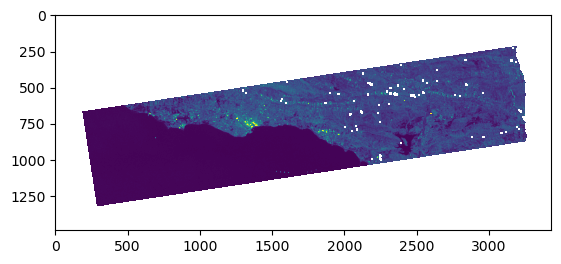

<Axes: >

In [5]:
show(X, vmin=0, vmax=.15)

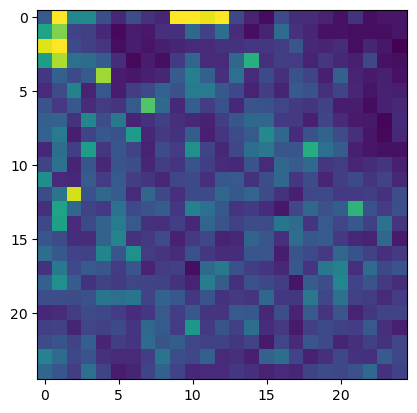

<Axes: >

In [6]:
sy = np.s_[600:625]
sx = np.s_[1100: 1_125]

show(X[sy, sx], vmin=0, vmax=.15)

In [7]:
p_c = get_cropped_profile(p, sx, sy)
p_c

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 25, 'height': 25, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]'), 'transform': Affine(30.0, 0.0, np.float64(244920.0),
       0.0, -30.0, np.float64(3816660.0)), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [8]:
df_post.shape

(15, 11)

In [9]:
df_pre.shape

(150, 11)

In [10]:
pre_vh_paths = df_pre.loc_path_vh.tolist()
pre_vv_paths = df_pre.loc_path_vv.tolist()

post_vh_paths = df_post.loc_path_vh.tolist()
post_vv_paths = df_post.loc_path_vv.tolist()

In [11]:
vv_paths = pre_vv_paths + post_vv_paths
vh_paths = pre_vh_paths + post_vh_paths

vv_paths[:3]

['out/10SGD/137/2024-07-06/OPERA_L2_RTC-S1_T137-292318-IW1_20240706T015901Z_20240708T000435Z_S1A_30_v1.0_VV.tif',
 'out/10SGD/137/2024-07-18/OPERA_L2_RTC-S1_T137-292318-IW1_20240718T015900Z_20240718T072557Z_S1A_30_v1.0_VV.tif',
 'out/10SGD/137/2024-07-30/OPERA_L2_RTC-S1_T137-292318-IW1_20240730T015900Z_20240730T064555Z_S1A_30_v1.0_VV.tif']

In [80]:

def crop_and_serialize_data(data_path: str) -> Path:
    p_out = Path(data_path.replace('out/10SGD/', 'test_data/10SGD_cropped/'))
    p_out.parent.mkdir(exist_ok=True, parents=True)
    with rasterio.open(data_path) as ds:
        X = ds.read(1)
        p = ds.profile
    p_c = get_cropped_profile(p, sx, sy)
    with rasterio.open(p_out, 'w', **p_c) as ds:
        ds.write(X[sy, sx], 1)
    return p_out

In [81]:
df_pre.loc_path_vh[0]

'out/10SGD/137/2024-07-06/OPERA_L2_RTC-S1_T137-292318-IW1_20240706T015901Z_20240708T000435Z_S1A_30_v1.0_VH.tif'

In [82]:
crop_and_serialize_data(df_pre.loc_path_vh[0])

PosixPath('test_data/10SGD_cropped/137/2024-07-06/OPERA_L2_RTC-S1_T137-292318-IW1_20240706T015901Z_20240708T000435Z_S1A_30_v1.0_VH.tif')

In [83]:
out_paths = list(map(crop_and_serialize_data, tqdm(vv_paths + vh_paths)))

100%|█| 330/330 [00:4


In [84]:
df_pre_test = df_pre.copy()
df_post_test = df_post.copy()

df_pre_test.loc_path_vh = df_pre.loc_path_vh.str.replace('out/10SGD/', 'test_data/10SGD_cropped/')
df_pre_test.loc_path_vv = df_pre.loc_path_vv.str.replace('out/10SGD/', 'test_data/10SGD_cropped/')

df_post_test.loc_path_vh = df_post.loc_path_vh.str.replace('out/10SGD/', 'test_data/10SGD_cropped/')
df_post_test.loc_path_vv = df_post.loc_path_vv.str.replace('out/10SGD/', 'test_data/10SGD_cropped/')

In [85]:
df_pre_test.to_parquet('test_data/10SGD_cropped/pre_10SGD.parquet')
df_post_test.to_parquet('test_data/10SGD_cropped/post_10SGD.parquet')

In [86]:
df_pre_test.head()

,opera_id,jpl_burst_id,acq_dt,acq_date,polarization,url_vh,url_vv,track_number,geometry,loc_path_vv,loc_path_vh
0,OPERA_L2_RTC-S1_T137-292318-IW1_20240706T01590...,T137-292318-IW1,2024-07-06 01:59:01+00:00,2024-07-06,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,137,"POLYGON ((-120.87989 33.88858, -119.86699 34.0...",test_data/10SGD_cropped/137/2024-07-06/OPERA_L...,test_data/10SGD_cropped/137/2024-07-06/OPERA_L...
1,OPERA_L2_RTC-S1_T137-292318-IW1_20240718T01590...,T137-292318-IW1,2024-07-18 01:59:00+00:00,2024-07-18,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,137,"POLYGON ((-120.88027 33.88844, -119.86739 34.0...",test_data/10SGD_cropped/137/2024-07-18/OPERA_L...,test_data/10SGD_cropped/137/2024-07-18/OPERA_L...
2,OPERA_L2_RTC-S1_T137-292318-IW1_20240730T01590...,T137-292318-IW1,2024-07-30 01:59:00+00:00,2024-07-30,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,137,"POLYGON ((-120.88131 33.88936, -119.86846 34.0...",test_data/10SGD_cropped/137/2024-07-30/OPERA_L...,test_data/10SGD_cropped/137/2024-07-30/OPERA_L...
3,OPERA_L2_RTC-S1_T137-292318-IW1_20240811T01590...,T137-292318-IW1,2024-08-11 01:59:00+00:00,2024-08-11,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,137,"POLYGON ((-120.88224 33.88919, -119.86935 34.0...",test_data/10SGD_cropped/137/2024-08-11/OPERA_L...,test_data/10SGD_cropped/137/2024-08-11/OPERA_L...
4,OPERA_L2_RTC-S1_T137-292318-IW1_20240823T01590...,T137-292318-IW1,2024-08-23 01:59:00+00:00,2024-08-23,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,137,"POLYGON ((-120.88231 33.88907, -119.86942 34.0...",test_data/10SGD_cropped/137/2024-08-23/OPERA_L...,test_data/10SGD_cropped/137/2024-08-23/OPERA_L...


In [87]:
vvs_pre = df_pre_test[df_pre_test.jpl_burst_id == 'T137-292319-IW2'].loc_path_vv.tolist()
vhs_pre = df_pre_test[df_pre_test.jpl_burst_id == 'T137-292319-IW2'].loc_path_vh.tolist()

vvs_post = df_post_test[df_post_test.jpl_burst_id == 'T137-292319-IW2'].loc_path_vv.tolist()
vhs_post = df_post_test[df_post_test.jpl_burst_id == 'T137-292319-IW2'].loc_path_vh.tolist()

In [88]:
vvs_pre_ids = [p.split('/')[-1][:-4] for p in vvs_pre]
vhs_pre_ids = [p.split('/')[-1][:-4] for p in vhs_pre]
vvs_post_ids = [p.split('/')[-1][:-4] for p in vvs_post]
vhs_post_ids = [p.split('/')[-1][:-4] for p in vhs_post]

In [89]:
vvs_pre_ids

['OPERA_L2_RTC-S1_T137-292319-IW2_20240706T015904Z_20240708T000435Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240718T015904Z_20240718T072557Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240730T015904Z_20240730T064555Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240811T015904Z_20240811T064742Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240823T015904Z_20240823T084936Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240904T015904Z_20240904T150822Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240916T015905Z_20240916T114330Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240928T015905Z_20240929T005548Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20241010T015906Z_20241010T101259Z_S1A_30_v1.0_VV',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20241022T015905Z_20241022T180854Z_S1A_30_v1.0_VV']

In [90]:
vhs_pre_ids

['OPERA_L2_RTC-S1_T137-292319-IW2_20240706T015904Z_20240708T000435Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240718T015904Z_20240718T072557Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240730T015904Z_20240730T064555Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240811T015904Z_20240811T064742Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240823T015904Z_20240823T084936Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240904T015904Z_20240904T150822Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240916T015905Z_20240916T114330Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20240928T015905Z_20240929T005548Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20241010T015906Z_20241010T101259Z_S1A_30_v1.0_VH',
 'OPERA_L2_RTC-S1_T137-292319-IW2_20241022T015905Z_20241022T180854Z_S1A_30_v1.0_VH']

In [91]:
vvs_post_ids

['OPERA_L2_RTC-S1_T137-292319-IW2_20241103T015905Z_20241103T071409Z_S1A_30_v1.0_VV']

In [92]:
vhs_post_ids

['OPERA_L2_RTC-S1_T137-292319-IW2_20241103T015905Z_20241103T071409Z_S1A_30_v1.0_VH']

In [93]:
sorted(df_pre.jpl_burst_id.unique().tolist())

['T137-292318-IW1',
 'T137-292318-IW2',
 'T137-292319-IW1',
 'T137-292319-IW2',
 'T137-292320-IW1',
 'T137-292320-IW2',
 'T137-292321-IW1',
 'T137-292321-IW2',
 'T137-292322-IW1',
 'T137-292322-IW2',
 'T137-292323-IW1',
 'T137-292323-IW2',
 'T137-292324-IW1',
 'T137-292324-IW2',
 'T137-292325-IW1']

In [94]:
post_dts = df_post_test[df_post_test.jpl_burst_id == 'T137-292319-IW2'].acq_dt.tolist()

In [95]:
pre_dts = df_pre_test[df_pre_test.jpl_burst_id == 'T137-292319-IW2'].acq_dt.tolist()

In [96]:
[dt.strftime('%Y%m%dT%H%M%S') for dt in post_dts]

['20241103T015905']

In [97]:
[dt.strftime('%Y%m%dT%H%M%S') for dt in pre_dts]

['20240706T015904',
 '20240718T015904',
 '20240730T015904',
 '20240811T015904',
 '20240823T015904',
 '20240904T015904',
 '20240916T015905',
 '20240928T015905',
 '20241010T015906',
 '20241022T015905']